# Import & Load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean_expenses.csv")

print("Data shape:", df.shape)
df.head()


Data shape: (30, 9)


,date,type,category,amount,payment_method,description,day_of_week,week,is_weekend
0,2026-01-01,income,income,1200000.0,transfer,Monthly salary,Thursday,1,False
1,2026-01-01,expense,bills,85000.0,cash,Internet subscription,Thursday,1,False
2,2026-01-02,expense,food,18000.0,cash,Grocery items,Friday,1,False
3,2026-01-02,expense,transport,5000.0,cash,Taxi ride,Friday,1,False
4,2026-01-03,expense,shopping,25000.0,card,House supplies,Saturday,1,True


# Basic Info

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     object 
 1   type            30 non-null     object 
 2   category        30 non-null     object 
 3   amount          30 non-null     float64
 4   payment_method  30 non-null     object 
 5   description     30 non-null     object 
 6   day_of_week     30 non-null     object 
 7   week            30 non-null     int64  
 8   is_weekend      30 non-null     bool   
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 2.0+ KB


# KPIs

In [3]:
total_expense = df['amount'].sum()
avg_expense = df['amount'].mean()
max_expense = df['amount'].max()

print("Total Expense:", total_expense)
print("Average Expense:", avg_expense)
print("Max Expense:", max_expense)


Total Expense: 1911000.0
Average Expense: 63700.0
Max Expense: 1200000.0


# Expenses by Category (Table)

In [4]:
category_summary = (
    df.groupby('category')['amount']
      .agg(['sum', 'mean', 'count'])
      .sort_values(by='sum', ascending=False)
)

category_summary


,sum,mean,count
category,,,
income,1325000.0,441666.666667,3
bills,210000.0,35000.000000,6
shopping,171000.0,34200.000000,5
food,154000.0,17111.111111,9
transport,51000.0,7285.714286,7


# Daily Trend (Line Plot)

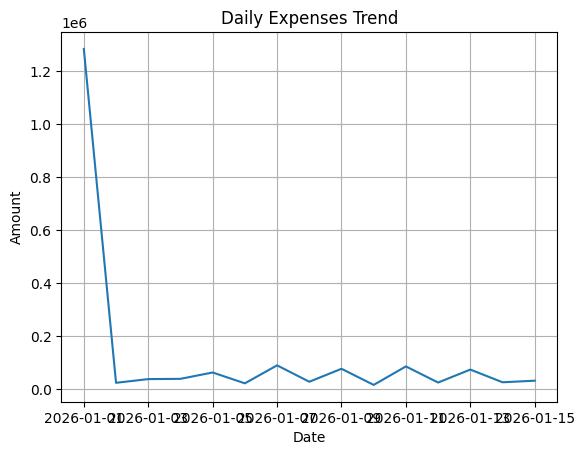

In [5]:
daily = df.groupby('date')['amount'].sum()

plt.figure()
daily.plot()
plt.title("Daily Expenses Trend")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.grid(True)
plt.show()


# Category Comparison (Bar Plot)

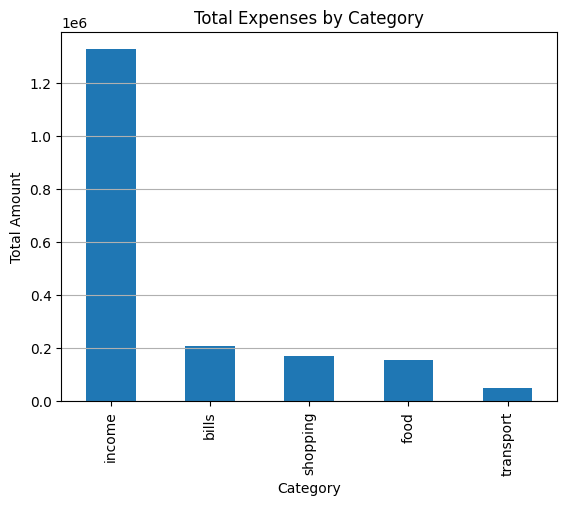

In [6]:
plt.figure()
category_summary['sum'].plot(kind='bar')
plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.grid(axis='y')
plt.show()


# Top 5 Expenses

In [7]:
top5 = df.sort_values(by='amount', ascending=False).head(5)
top5


,date,type,category,amount,payment_method,description,day_of_week,week,is_weekend
0,2026-01-01,income,income,1200000.0,transfer,Monthly salary,Thursday,1,False
1,2026-01-01,expense,bills,85000.0,cash,Internet subscription,Thursday,1,False
13,2026-01-07,income,income,75000.0,cash,Side job,Wednesday,2,False
20,2026-01-11,expense,shopping,65000.0,card,Small electronics,Sunday,2,True
17,2026-01-09,expense,bills,50000.0,transfer,Electricity bill,Friday,2,False


# Weekly Summary

In [9]:
weekly = df.groupby('week')['amount'].sum()
weekly


week
1    1383000.0
2     375000.0
3     153000.0
Name: amount, dtype: float64

# Save Report Tables

In [10]:
category_summary.to_csv("category_summary.csv")
weekly.to_csv("weekly_summary.csv")

print("Reports saved successfully.")


Reports saved successfully.
